# CEMA Analysis & Metrics
Load captured EM traces, compute side-channel metrics (TVLA, CEMA, SNR), and prepare outputs for MATLAB PSO optimization.

## Imports and Parameters

In [25]:
# Imports
import chipwhisperer as cw
import sys
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from scipy.stats import ttest_ind
from scipy.io import savemat
try:
    from sklearn.mixture import GaussianMixture
except:
    print("Warning: scikit-learn not available. GMM generation will be skipped.")

sys.path.insert(1, '../../SCApeGoat-main/')

from WPI_SCA_LIBRARY.CWScope import *
from WPI_SCA_LIBRARY.LeakageModels import *
%run "../function/CEMA_functions.ipynb"
%run "../function/AES_model.ipynb"


# Global Parameters
probe_diameter = "1.2mm"  # Same for all platforms

## Data Source Selection
Choose between loading from live capture experiments or pre-made public datasets.

In [2]:
# Initialize SCApeGoat experiment manager
emsca = FileParent("CEMA", "./", True)

# ===== SELECT DATA SOURCE =====
# DATA_SOURCE options:
#   - "CAPTURE": Load from locally captured SCApeGoat experiments
#   - "PUBLIC": Load from pre-captured public datasets (authors' reference)
DATA_SOURCE = "PUBLIC"  # Change to "CAPTURE" if using your own captured data

print(f"Data Source: {DATA_SOURCE}")

Data Source: PUBLIC


## Data Selection & Configuration

In [3]:
if DATA_SOURCE == "CAPTURE":
    # ===== Configuration for Captured Data =====
    TARGET = "FPGA"  # Options: "FPGA" or "UC"
    FPGA_VARIANT = "impl_3"  # Options: "impl_3", "impl_1", or other variants (ignored for UC)
    n_steps = 10         # Grid size (10x10)
    N_traces = 10000     # Traces per grid position
    
    if TARGET == "FPGA":
        dut = "CW305"
        bitfile = f"{FPGA_VARIANT}.bit"
        print(f"Target: FPGA (CW305)")
        print(f"Bitfile: {bitfile}")
    elif TARGET == "UC":
        dut = "CW-Lite"
        bitfile = None
        print(f"Target: Microcontroller (CW Lite)")
    
    print(f"Grid: {n_steps}x{n_steps}")
    print(f"Traces per position: {N_traces}")

elif DATA_SOURCE == "PUBLIC":
    # ===== Configuration for Public Datasets =====
    # Pre-captured and preprocessed reference datasets from authors
    # Available options: "impl_d" (default), "impl_1", "impl_3", "uc"
    PUBLIC_DATASET = "impl_3"  # Change to "impl_d", "impl_1", or "uc" as needed
    
    print(f"\nLoading public dataset: {PUBLIC_DATASET}")
    
    if PUBLIC_DATASET == "impl_d":
        test = emsca.get_experiment('fpga_cema_1_2mm_10000_10x10_40x_default_avg')
        test_avg = emsca.get_experiment('fpga_cema_1_2mm_10000_10x10_40x_default_avg_reduced')
        test_t = emsca.get_experiment('fpga_cema_1_2mm_10000_10x10_40x_default_avg_reduced_t')
        dut = "CW305"
        variant = "default"
        TARGET = "FPGA"
        print(f"Loaded: FPGA default implementation")
    elif PUBLIC_DATASET == "impl_1":
        test = emsca.get_experiment('fpga_cema_1_2mm_10000_10x10_40x_impl_1_avg')
        test_avg = emsca.get_experiment('fpga_cema_1_2mm_10000_10x10_40x_impl_1_avg_reduced')
        test_t = emsca.get_experiment('fpga_cema_1_2mm_10000_10x10_40x_impl_1_avg_reduced_t')
        dut = "CW305"
        variant = "impl_1"
        TARGET = "FPGA"
        print(f"Loaded: FPGA impl_1")
    elif PUBLIC_DATASET == "impl_3":
        test = emsca.get_experiment('fpga_cema_1_2mm_10000_10x10_40x_impl_3_avg')
        test_avg = emsca.get_experiment('fpga_cema_1_2mm_10000_10x10_40x_impl_3_avg_reduced')
        test_t = emsca.get_experiment('fpga_cema_1_2mm_10000_10x10_40x_impl_3_avg_reduced_t')
        dut = "CW305"
        variant = "impl_3"
        TARGET = "FPGA"
        print(f"Loaded: FPGA impl_3")
    elif PUBLIC_DATASET == "uc":
        test = emsca.get_experiment('uc_cema_1_2mm_10000_10x10_30x_avg')
        test_avg = emsca.get_experiment('uc_cema_1_2mm_10000_10x10_30x_avg_a')
        test_t = emsca.get_experiment('uc_cema_1_2mm_10000_10x10_30x_avg_t')
        dut = "CW-Lite"
        variant = "uc"
        TARGET = "UC"
        print(f"Loaded: UC (microcontroller)")
    else:
        raise ValueError(f"Unknown PUBLIC_DATASET: {PUBLIC_DATASET}")
    
    N_traces = 1000  # Public datasets are pre-averaged/reduced
    n_steps = 10


Loading public dataset: impl_3
Loaded: FPGA impl_3


## Data Preprocessing (Optional)
The following preprocessing functions are available in CEMA_functions.ipynb for fresh CAPTURE data.
Public datasets are pre-processed and do not require these steps.

In [4]:
# Preprocessing functions are defined in CEMA_functions.ipynb
# Uncomment and use only for fresh CAPTURE data (not needed for PUBLIC datasets)

# =====AVERAGING: Reduces noise through trace averaging=====
# Pros: Significantly reduces noise in each grid position
# Cons: Reduces effective sample size (averaging N traces into 1)
# Use when: Traces are very noisy or computation is time-critical
# Example (uncomment to use with CAPTURE data):
#   if DATA_SOURCE == "CAPTURE":
#       test_avg = test_to_avg(test, test_copy, avg=10, grid_size=(n_steps, n_steps))

# ===== RANDOM SAMPLING: Maintains trace diversity =====
# Pros: Maintains diversity; faster than averaging for large datasets
# Cons: Less noise reduction than averaging; still reduces sample size
# Use when: You want to balance noise reduction with sample diversity
# Example (uncomment to use with CAPTURE data):
#   if DATA_SOURCE == "CAPTURE":
#       test_avg = test_to_randomsample(test, test_copy, n_samples=30, grid_size=(n_steps, n_steps))

# NOTE: Public datasets (impl_d, impl_3, uc) are already pre-processed.
# The _reduced and _avg variants already have averaging applied.
print("Preprocessing options available in CEMA_functions.ipynb")

Preprocessing options available in CEMA_functions.ipynb


## Load Data from Experiments or Files

In [5]:
if DATA_SOURCE == "CAPTURE":
    # ===== Load from SCApeGoat Experiments (CAPTURE) =====
    # Build experiment name matching capture notebook output
    experiment_name = f"{TARGET.lower()}_{probe_diameter.replace('.', '').replace('mm', '')}_{N_traces}_{n_steps}x{n_steps}"
    
    try:
        test = emsca.get_experiment(experiment_name)
        print(f"Loaded experiment: {experiment_name}")
        print(f"Shape: {test.data.shape}")
    except Exception as e:
        print(f"ERROR: Could not load experiment '{experiment_name}'")
        print(f"Available experiments: {list(emsca.experiments.keys())}")
        raise

elif DATA_SOURCE == "PUBLIC":
    # ===== Public Datasets Already Loaded =====
    # SCApeGoat experiments were loaded in the configuration cell above
    # (test, test_avg, test_t are now available)
    print(f"\nPublic dataset configuration complete.")
    print(f"  Test set: {test.name}")
    print(f"  Avg set:  {test_avg.name}")
    print(f"  T-test set: {test_t.name}")
    print(f"  DUT: {dut}, Variant: {variant}")


Public dataset configuration complete.
  Test set: fpga_cema_1_2mm_10000_10x10_40x_impl_3_avg
  Avg set:  fpga_cema_1_2mm_10000_10x10_40x_impl_3_avg_reduced
  T-test set: fpga_cema_1_2mm_10000_10x10_40x_impl_3_avg_reduced_t
  DUT: CW305, Variant: impl_3


## Load Plaintext/Key Data

In [29]:
# Select which PT/keys experiment to use
# Options: 'pt_keys' (default), 'pt_keys_5k_rambus', 'pt_keys_5kx10_rambus'
PT_SELECTION = 'pt_keys_5k_rambus'  # change to 'pt_keys_5k_rambus' or 'pt_keys_5kx10_rambus' if needed
# Choose which plaintext set to use for metrics: 'random' or 'fixed'
METRICS_PT_CHOICE = 'random'

# Resolve experiment
try:
    if PT_SELECTION == 'pt_keys':
        pt = emsca.get_experiment('pt_keys')
    elif PT_SELECTION == 'pt_keys_5k_rambus':
        pt = emsca.get_experiment('pt_keys_5k_rambus')
    elif PT_SELECTION == 'pt_keys_5kx10_rambus':
        pt = emsca.get_experiment('pt_keys_5kx10_rambus')
    else:
        raise ValueError(f"Unknown PT_SELECTION: {PT_SELECTION}")
except Exception as e:
    print(f"WARNING: could not load selected PT experiment '{PT_SELECTION}': {e}")
    pt = None

if pt is None:
    print("WARNING: Plaintext/Keys experiment not available. Some metrics may fail.")
    pt = None
    keys = None
else:
    # Read the standard datasets (same loading pattern used previously)
    try:
        keys_pt = pt.get_dataset('keys').read_data(0, 10000)
    except Exception:
        keys_pt = None
    try:
        random_pt = pt.get_dataset('plaintexts').read_data(0, 10000)
    except Exception:
        random_pt = None
    try:
        fixed_pt = pt.get_dataset('fixed_pt').read_data(0, 10000)
    except Exception:
        fixed_pt = None

    print(f"Loaded PT experiment: {pt.name}")
    print(f"  keys: {None if keys_pt is None else keys_pt.shape}")
    print(f"  random plaintexts: {None if random_pt is None else random_pt.shape}")
    print(f"  fixed plaintexts: {None if fixed_pt is None else fixed_pt.shape}")

    # # Select which plaintexts to use for metric computations
    # if METRICS_PT_CHOICE == 'random':
    #     pt = random_pt
    # else:
    #     pt = fixed_pt
    # keys = keys_pt
    # print(f"Metrics will use plaintext set: {METRICS_PT_CHOICE}")

Loaded PT experiment: pt_keys_5k_rambus
  keys: (10000, 16)
  random plaintexts: (5000, 16)
  fixed plaintexts: (5000, 16)


## Compute Metrics: TVLA (t-statistic)

In [7]:
# Determine rotation_n based on target
if TARGET == "FPGA":
    rotation_n = 2
else:  # UC
    rotation_n = 3

print(f"Rotation parameter: rotation_n={rotation_n} (TARGET={TARGET})")

Rotation parameter: rotation_n=2 (TARGET=FPGA)


Computing TVLA t-statistic heatmap...


Calculating T-Test:   0%|          | 0/1000 [00:00<?, ?it/s]D:\ChipWhisperer5_64\cw\home\portable\chipwhisperer\EMSCA\CEMA\../../SCApeGoat-main\WPI_SCA_LIBRARY\Metrics.py:161: RuntimeWarning: invalid value encountered in divide
  welsh_t = np.array(new_mr - new_mf) / np.sqrt(
Calculating T-Test: 100%|██████████| 1000/1000 [00:00<00:00, 41762.63it/s]


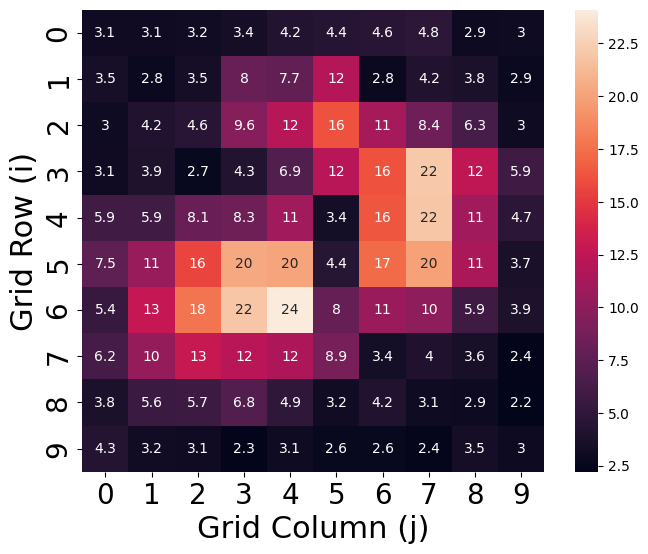

TVLA computation complete
t-statistic shape: 2


C:\Users\Riscure\AppData\Local\Temp\ipykernel_42836\3561301180.py:8: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  print(f"Max t-value: {np.nanmax(np.abs(t_values)):.2f}")


TypeError: bad operand type for abs(): 'Figure'

In [8]:
# Compute TVLA (Welch's t-test) heatmap across grid
print("Computing TVLA t-statistic heatmap...")

t_values = plot_t_statistic_heatmap(test_t, grid_size=n_steps, rotation_n=rotation_n)

print(f"TVLA computation complete")
print(f"t-statistic shape: {len(t_values)}")
print(f"Max t-value: {np.nanmax(np.abs(t_values)):.2f}")

In [17]:
labels = np.load('labels_13.npy', allow_pickle=True)


# MI Computation

## for FPGA 1 and 2

In [18]:

import os

grid = 11
nystrom = False # true if you want the nystrom
landmarks = 700 # 700 for FPGA1 , 280 for FPGA2 and 180 for FPGA3
k=2

root = 'MI_directory/FPGA2'
labels = np.load('labels_13.npy', allow_pickle=True)




MI_values = np.zeros((grid,grid))
path1 = root

for i in range(grid):
    for j in range(grid):
        path2 = f"random_{i}_{j}.npy"
        full_path = os.path.join(path1, path2)
        tr = np.load(full_path)
        

        
        

        MI_values[i, j] = HXX(tr ,labels , 1.01 , False , 280)

MI_values_rotated = np.rot90(MI_values, k=2)
        
        

In [20]:
from scipy.io import savemat
savemat("FPGA2_HXCELL.mat", {"HXcell": SNR_values_rotated})



## Uc dataset

In [21]:
import os

grid = 2
nystrom = False # true if you want the nystrom
landmarks = 180 # 700 for FPGA1 , 280 for FPGA2 and 180 for uc
k=3

traces = np.load('MI_directory/uc_traces.npy')
labels = np.load('MI_directory/uc_labels.npy', allow_pickle=True)




MI_values = np.zeros((grid,grid))
path1 = root

for i in range(grid):
    for j in range(grid):

        tr = traces[i,j]
        

        
        

        MI_values[i, j] = HXX(tr ,labels , 1.01 , False , 280)

MI_values_rotated = np.rot90(MI_values, k=2)

## Compute Metrics: CEMA (Correlation EM Analysis)

Computing CEMA correlation heatmap...


  0%|          | 0/10 [00:00<?, ?it/s]

Processing grid position (0, 0)


 10%|█         | 1/10 [00:02<00:20,  2.23s/it]

Processing grid position (0, 1)


...

 80%|████████  | 8/10 [00:17<00:04,  2.21s/it]

Processing grid position (9, 8)


 90%|█████████ | 9/10 [00:19<00:02,  2.16s/it]

Processing grid position (9, 9)


100%|██████████| 10/10 [00:21<00:00,  2.15s/it]


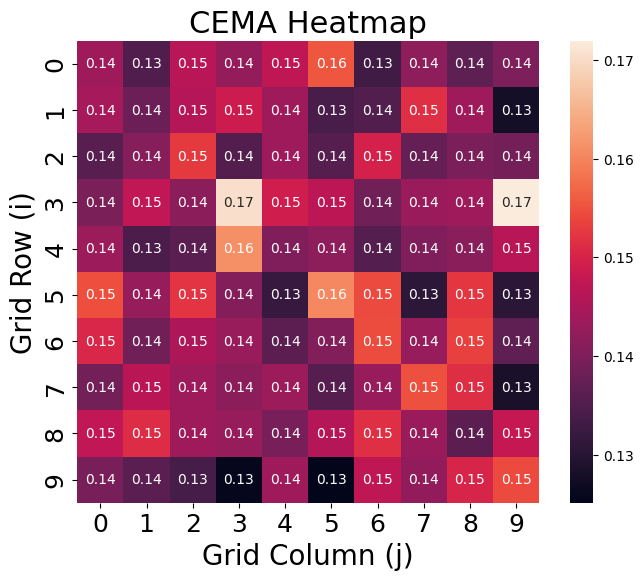

CEMA computation complete
CEMA shape: (10, 10)


TypeError: unsupported format string passed to numpy.ndarray.__format__

In [16]:
# Compute CEMA heatmap across grid
print("Computing CEMA correlation heatmap...")

CEMA, CEMA_max = plot_CEMA_heatmap(
    test,
    pt,  
    num=N_traces,
    grid_size=n_steps,
    rotation_n=rotation_n,
    lower_b=35  # Sample range for correlation computation
)

print(f"CEMA computation complete")
print(f"CEMA shape: {CEMA.shape}")
print(f"Max CEMA correlation: {CEMA_max:.4f}")

## Compute Metrics: MI (Mutual Information)
Compute MI for PSO optimization input.

**Note:** The `plot_MI_heatmap()` function should be added to CEMA_functions.ipynb if not already present.
It implements kernel-based Renyi entropy estimation with the following signature:
```
plot_MI_heatmap(test, plaintexts, num_traces, grid_size, rotation_n=2, MI_type="BYTE", 
                target_byte=0, nystrom=False, m_l=1000, r1=0.1, r2=10.0)
```
- `MI_type`: "BYTE" for per-byte MI, or "ALL" for combined MI
- `target_byte`: Which byte to compute MI for (0-15)
- `nystrom`: If True, use Nystrom approximation for speed
- `m_l`: Number of Nystrom samples
- `r1, r2`: Bandwidth parameters for kernel estimation

In [ ]:
# Compute Mutual Information heatmap
print("Computing Mutual Information (MI) heatmap...")
print("(This may take several minutes on large datasets...)")

# MI computation using HW leakage model
# Use nystrom=True for faster computation on large datasets
MI = plot_MI_heatmap(
    test,
    pt,
    num_traces=N_traces,
    grid_size=n_steps,
    rotation_n=rotation_n,
    MI_type="BYTE",
    target_byte=0,
    nystrom=False,  # Set to True for faster approximation
    m_l=1000
)

print(f"\nMI computation complete")
print(f"MI shape: {MI.shape}")
print(f"Max MI: {np.nanmax(MI):.4f}")
print(f"Mean MI: {np.nanmean(MI):.4f}")

## Optional: CPA Traces at Specific Location
Visualize correlation traces at a specific grid position to inspect leakage patterns.


Analyzing CPA traces for FPGA
Coordinates: [(6, 5)]
Grid size: (11, 11)
Rotation parameter: 2

  Byte  0 | Coord (6, 5) → (4, 5) ... 

100%|██████████| 999/999 [00:03<00:00, 313.12it/s] 


0
Shape of maxcpa_matrix: (100, 256)


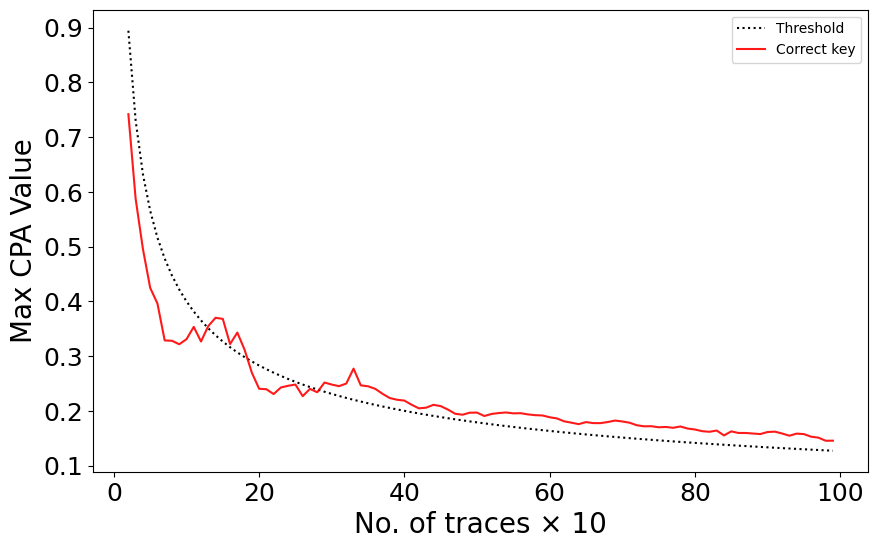

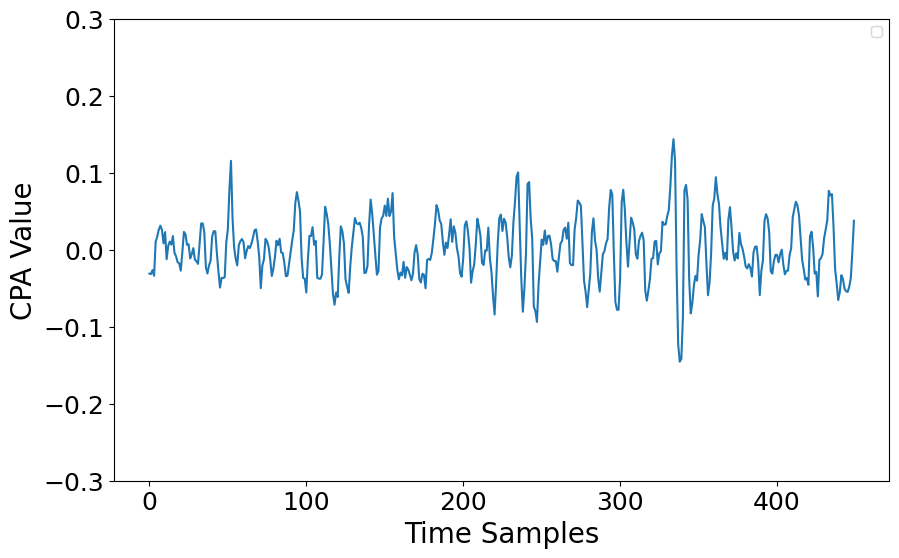

✅ CPA crosses threshold permanently at index 27 (≈ 290 traces)
Min traces: 290
  Byte  1 | Coord (6, 5) → (4, 5) ... 

100%|██████████| 999/999 [00:02<00:00, 341.59it/s] 

1
Shape of maxcpa_matrix: (100, 256)


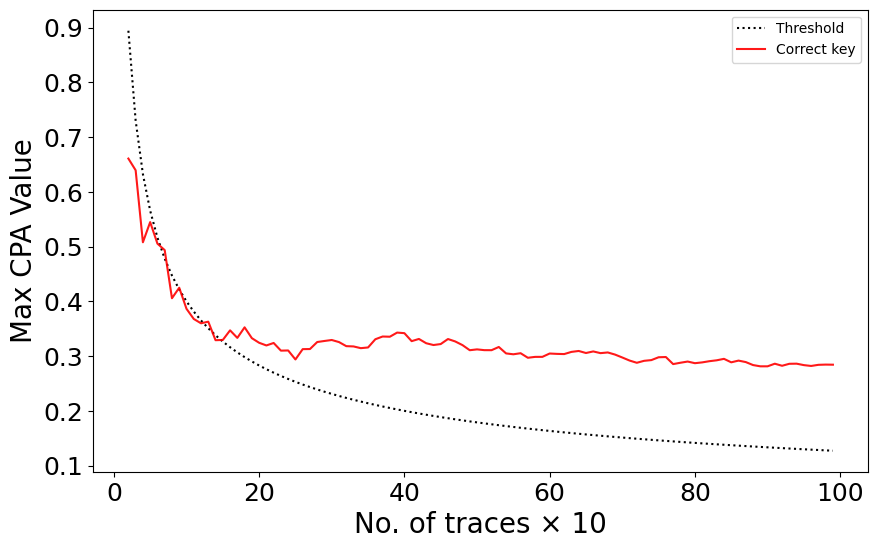

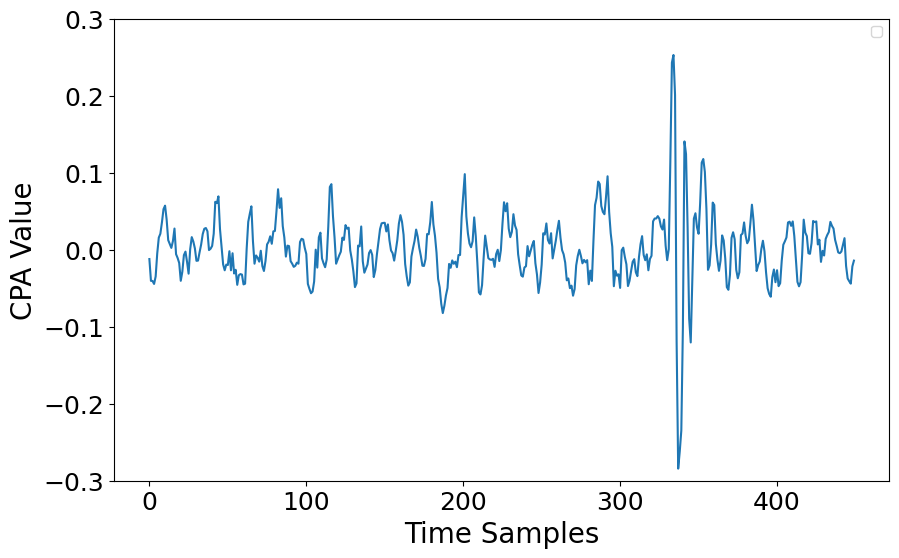

✅ CPA crosses threshold permanently at index 13 (≈ 150 traces)
Min traces: 150
  Byte  2 | Coord (6, 5) → (4, 5) ... 

100%|██████████| 999/999 [00:02<00:00, 334.18it/s] 

2
Shape of maxcpa_matrix: (100, 256)


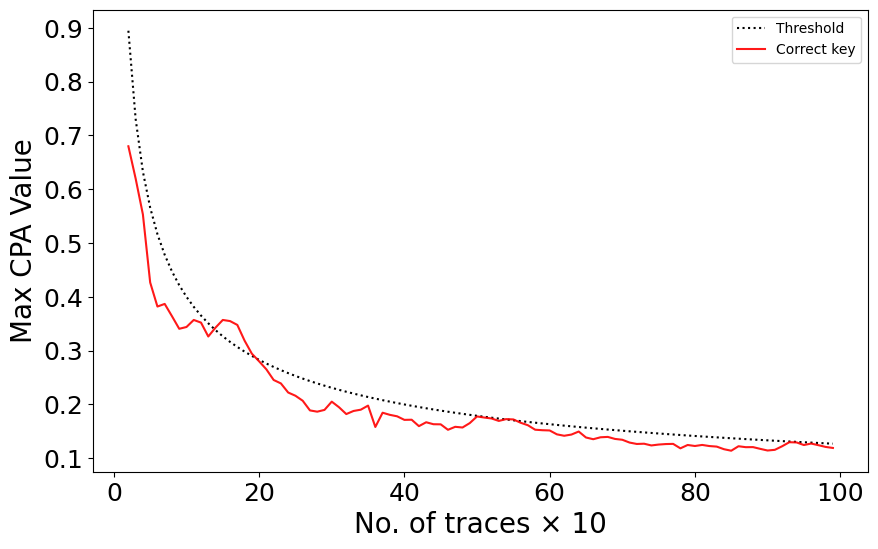

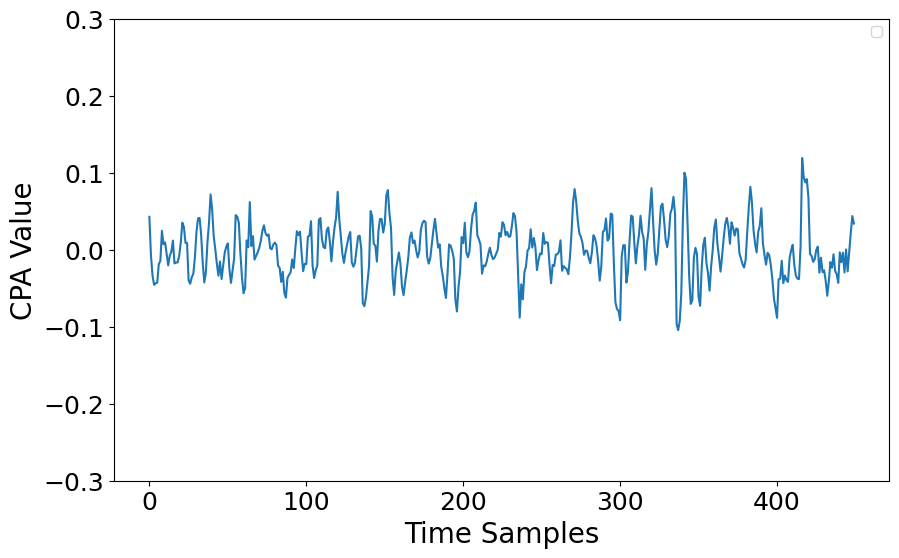

⚠️ CPA never stays permanently above the threshold.
Min traces: N/A
  Byte  3 | Coord (6, 5) → (4, 5) ... 

100%|██████████| 999/999 [00:02<00:00, 339.44it/s] 


3
Shape of maxcpa_matrix: (100, 256)


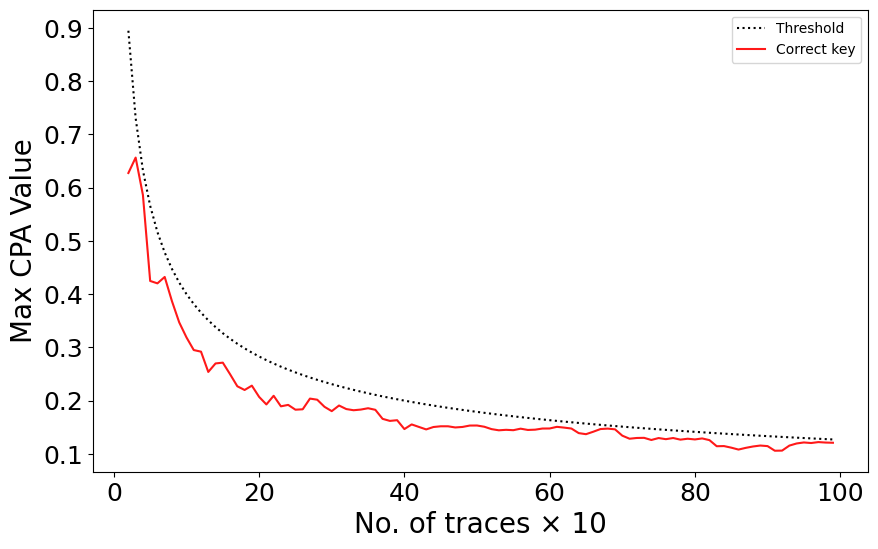

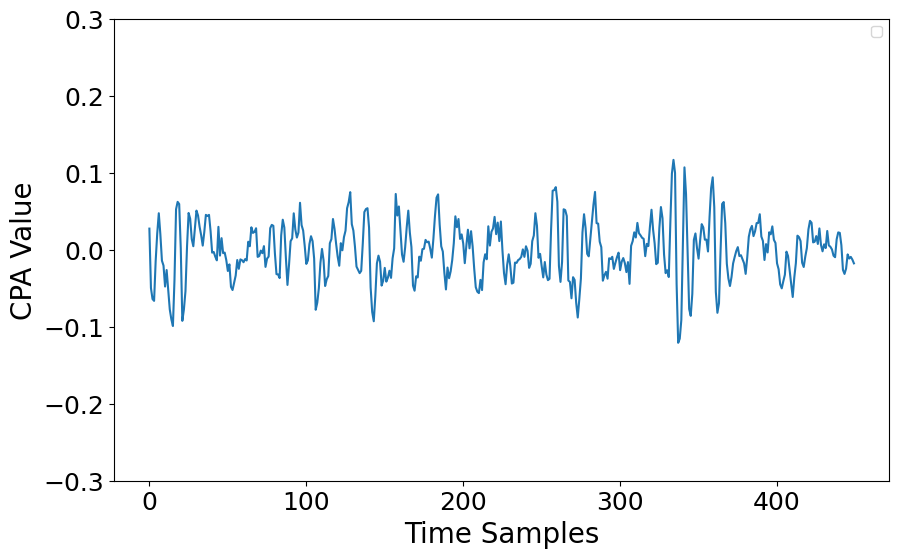

⚠️ CPA never stays permanently above the threshold.
Min traces: N/A
  Byte  4 | Coord (6, 5) → (4, 5) ... 

100%|██████████| 999/999 [00:02<00:00, 338.46it/s] 


4
Shape of maxcpa_matrix: (100, 256)


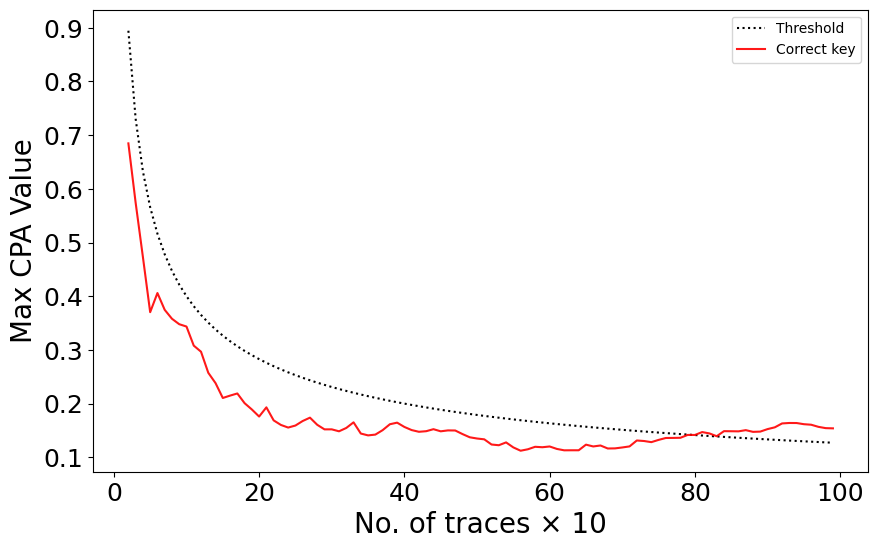

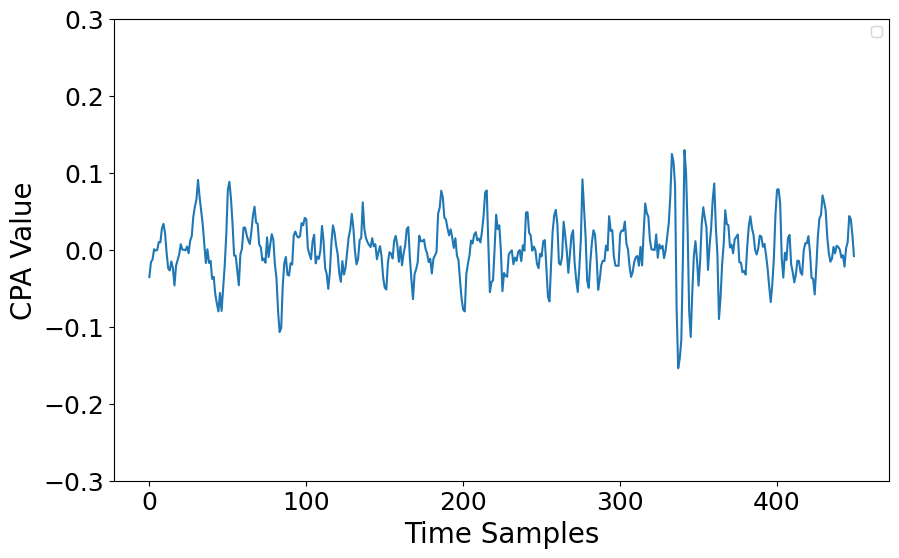

✅ CPA crosses threshold permanently at index 78 (≈ 800 traces)
Min traces: 800
  Byte  5 | Coord (6, 5) → (4, 5) ... 

100%|██████████| 999/999 [00:03<00:00, 331.31it/s] 


5
Shape of maxcpa_matrix: (100, 256)


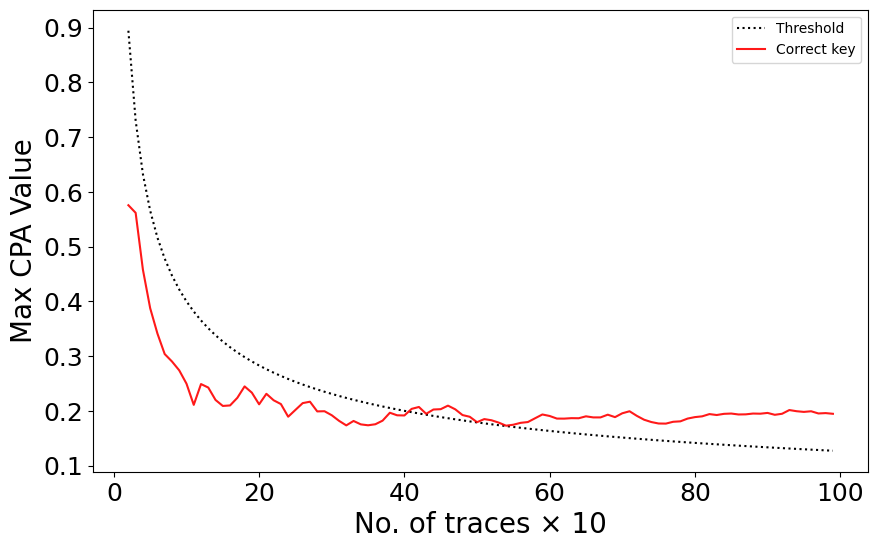

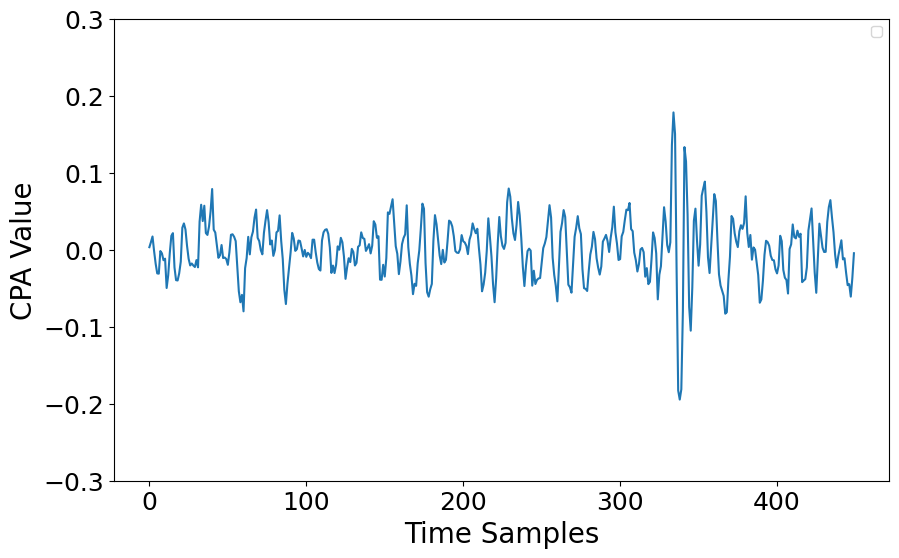

✅ CPA crosses threshold permanently at index 39 (≈ 410 traces)
Min traces: 410
  Byte  6 | Coord (6, 5) → (4, 5) ... 

100%|██████████| 999/999 [00:02<00:00, 333.39it/s] 

6
Shape of maxcpa_matrix: (100, 256)


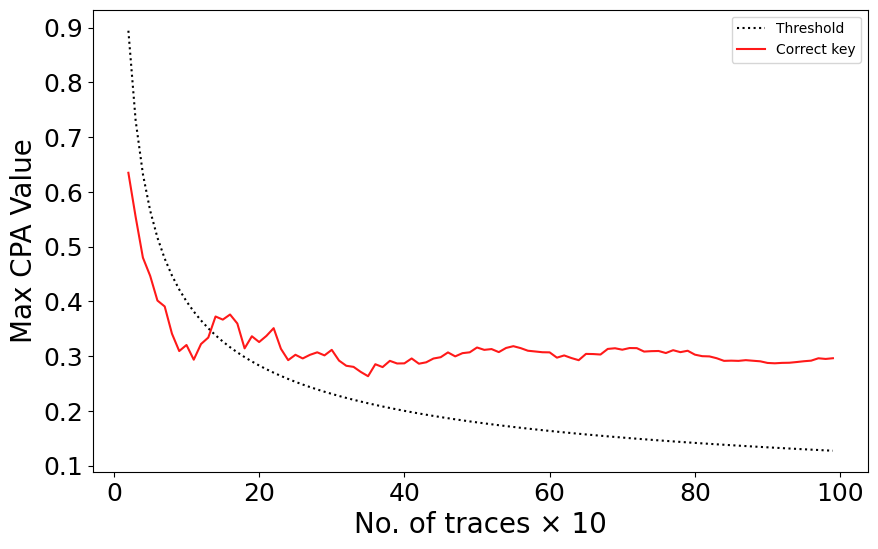

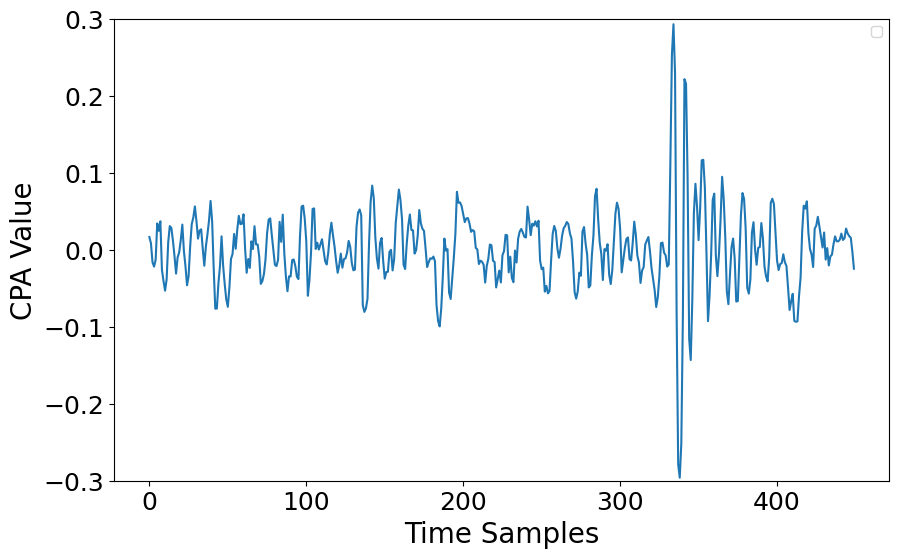

✅ CPA crosses threshold permanently at index 12 (≈ 140 traces)
Min traces: 140
  Byte  7 | Coord (6, 5) → (4, 5) ... 

100%|██████████| 999/999 [00:02<00:00, 334.20it/s] 


7
Shape of maxcpa_matrix: (100, 256)


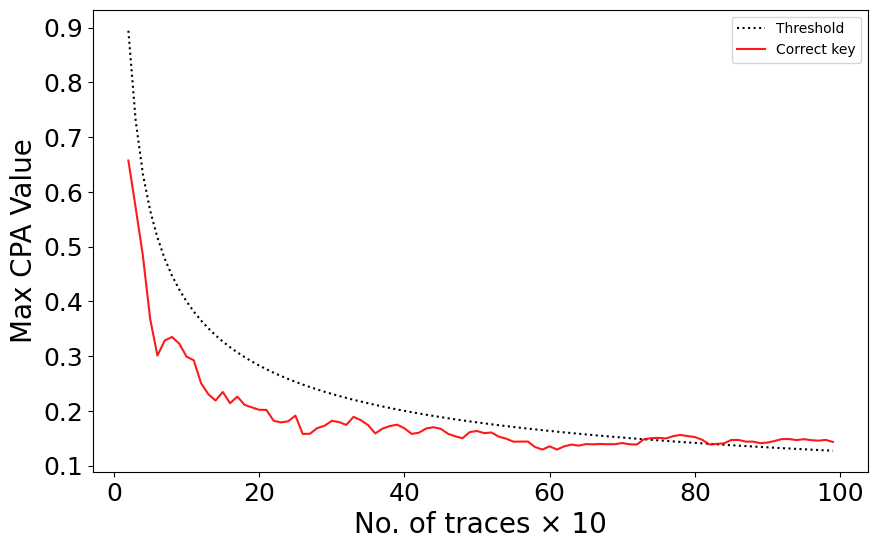

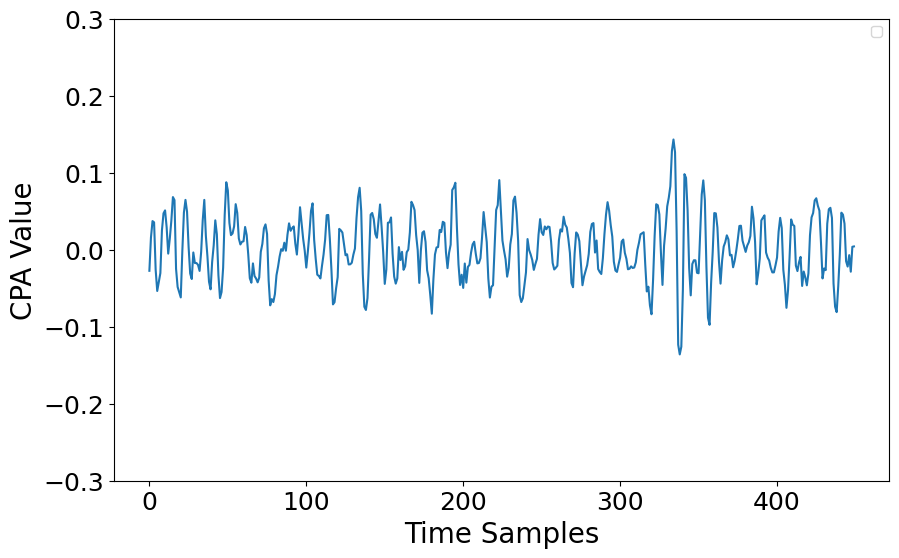

✅ CPA crosses threshold permanently at index 81 (≈ 830 traces)
Min traces: 830
  Byte  8 | Coord (6, 5) → (4, 5) ... 

100%|██████████| 999/999 [00:02<00:00, 343.22it/s] 

8
Shape of maxcpa_matrix: (100, 256)


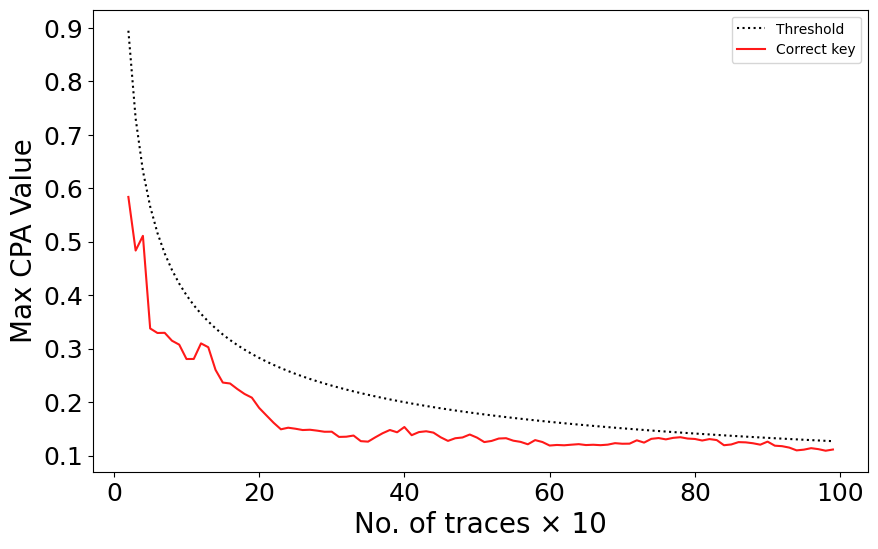

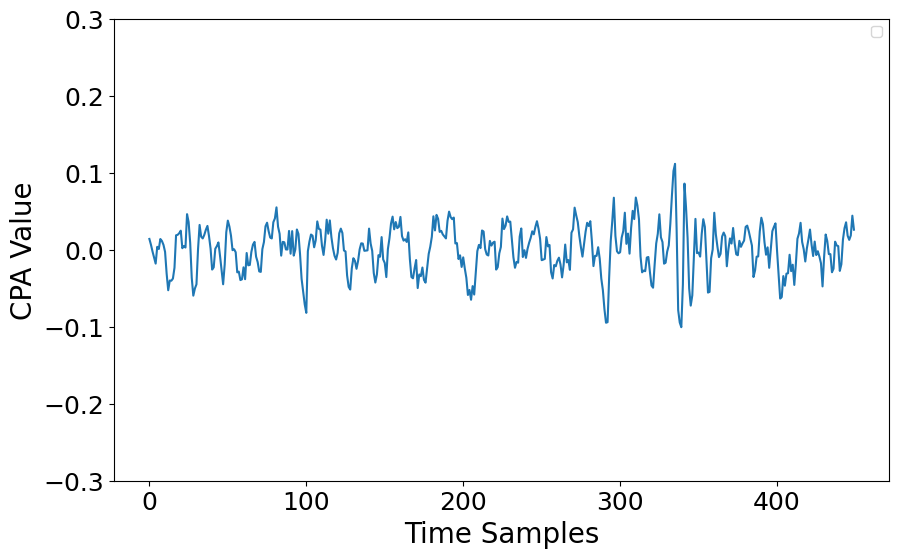

⚠️ CPA never stays permanently above the threshold.
Min traces: N/A
  Byte  9 | Coord (6, 5) → (4, 5) ... 

100%|██████████| 999/999 [00:02<00:00, 343.97it/s] 

9
Shape of maxcpa_matrix: (100, 256)


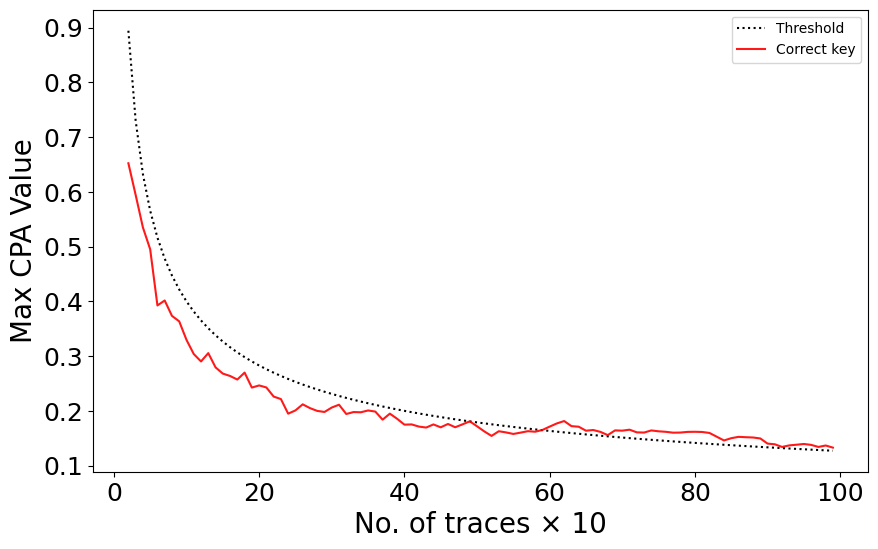

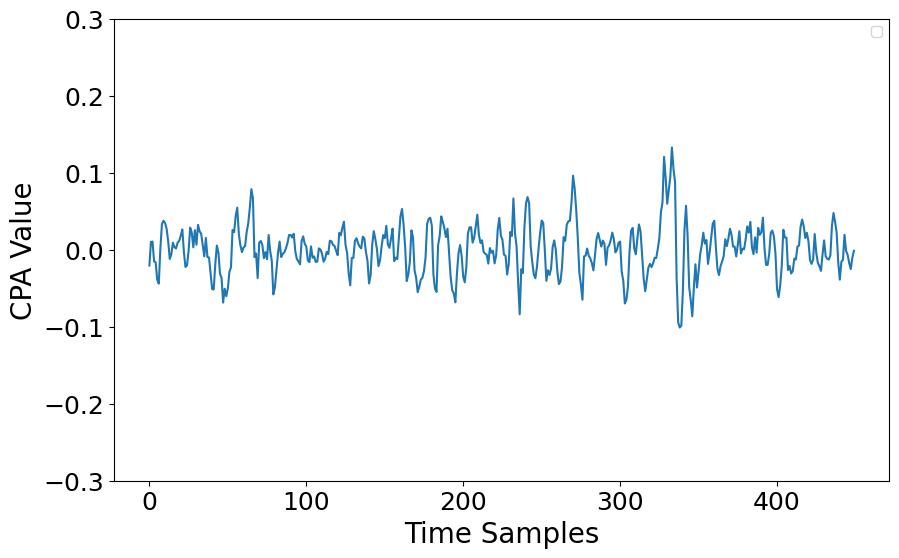

✅ CPA crosses threshold permanently at index 57 (≈ 590 traces)
Min traces: 590
  Byte 10 | Coord (6, 5) → (4, 5) ... 

100%|██████████| 999/999 [00:03<00:00, 329.57it/s] 


10
Shape of maxcpa_matrix: (100, 256)


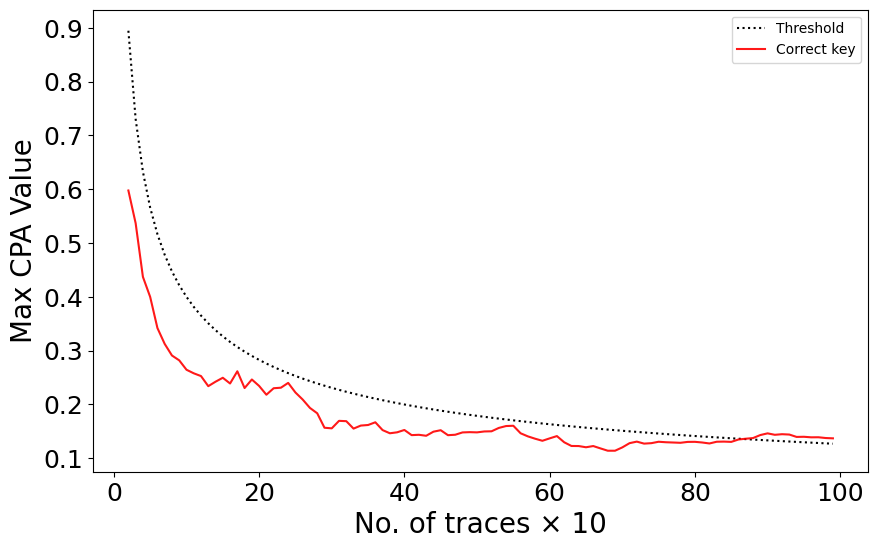

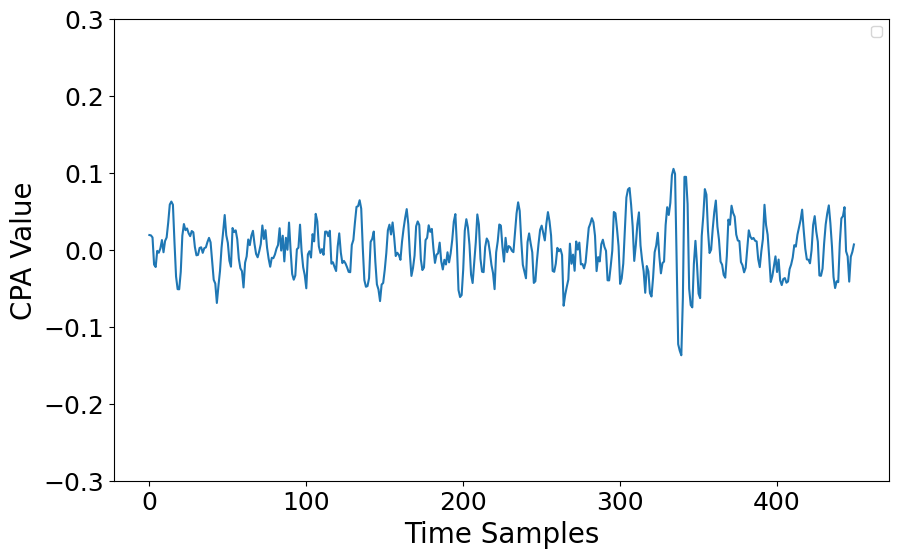

✅ CPA crosses threshold permanently at index 85 (≈ 870 traces)
Min traces: 870

Summary of Minimum Traces per Location and Byte

Coord        Rotated      Byte   Min Traces     
----------------------------------------------------------------------
(6,5)        (4,5)        0      290            
(6,5)        (4,5)        1      150            
(6,5)        (4,5)        2      N/A            
(6,5)        (4,5)        3      N/A            
(6,5)        (4,5)        4      800            
(6,5)        (4,5)        5      410            
(6,5)        (4,5)        6      140            
(6,5)        (4,5)        7      830            
(6,5)        (4,5)        8      N/A            
(6,5)        (4,5)        9      590            
(6,5)        (4,5)        10     870            

Optional CPA visualization available (uncomment above to enable)


In [30]:
# Uncomment and adjust the following to visualize CPA patterns at a specific grid location

# Select a high-MI location to analyze
# GRID_I, GRID_J = 5, 5  # Modify to select grid position


# Analyze CPA traces at specific grid locations for each byte
# Configure parameters below for UC vs FPGA

# ===== CONFIGURATION =====
# Select target: "UC" or "FPGA"
CPA_TARGET = "FPGA"

# Grid and coordinate settings
grid_size = (11, 11)
coords = [(6,5)]  # Grid locations to analyze

# Byte range to analyze
byte_range = range(0, 11)

# ===== MODEL-SPECIFIC PARAMETERS =====
# Modify these parameters based on your target and leakage model

if CPA_TARGET == "UC":
    # UC Configuration
    source_experiment = test_avg  # Data source
    rotation_n = 3
    num_traces = 1000
    
    # plot_CEMA_traces_temp parameters for UC
    cpa_params = {
        'div': 10,
        'visualize_correct': True,
        'model': 1,          # Change as needed for UC
        'r1': 6,             # Bandwidth parameter 1
        'r2': 7,             # Bandwidth parameter 2
        'col_tar': 'sbb_o'   # Column target
    }
    
elif CPA_TARGET == "FPGA":
    # FPGA Configuration
    source_experiment = test_avg  # Change to your FPGA data source
    rotation_n = 2
    num_traces = 1000
    
    # plot_CEMA_traces_temp parameters for FPGA
    cpa_params = {
        'div': 10,
        'visualize_correct': True,
        'model': 2,          # Change as needed for FPGA
        'r1': 6,             # round 1
        'r2': 7,             # round 2
        'col_tar': 'sbb_o'   # Column target
    }
else:
    raise ValueError(f"Unknown CPA_TARGET: {CPA_TARGET}")

# ===== EXECUTION =====
print(f"\nAnalyzing CPA traces for {CPA_TARGET}")
print(f"Coordinates: {coords}")
print(f"Grid size: {grid_size}")
print(f"Rotation parameter: {rotation_n}\n")

results = []
for byte_i in byte_range:
    for (x, y) in coords:
        i, j = reverse_coords_ccw(x, y, grid_size, rotation_n)
        print(f"  Byte {byte_i:2d} | Coord ({x}, {y}) → ({i}, {j})", end=' ... ')
        
        # Load traces
        temp_trace = source_experiment.get_dataset(f"random_{i}_{j}").read_all()
        
        # Compute CEMA
        m, c, f, min_traces = plot_CEMA_traces_temp(
            temp_trace,
            pt,  # Plaintext data
            num_traces,
            target_byte=byte_i,
            **cpa_params
        )
        
        results.append((x, y, i, j, min_traces, byte_i))
        print(f"Min traces: {int(min_traces) if min_traces is not None else 'N/A'}")

# ===== PRINT SUMMARY TABLE =====
print("\n" + "="*70)
print("Summary of Minimum Traces per Location and Byte")
print("="*70 + "\n")
print(f"{'Coord':<12} {'Rotated':<12} {'Byte':<6} {'Min Traces':<15}")
print("-" * 70)

for (x, y, i, j, min_traces, byte_i) in results:
    coord_str = f"({x},{y})"
    rot_str = f"({i},{j})"
    val_str = f"{int(min_traces)}" if min_traces is not None else "N/A"
    print(f"{coord_str:<12} {rot_str:<12} {byte_i:<6} {val_str:<15}")

print("\n" + "="*70)

print("Optional CPA visualization available (uncomment above to enable)")

## Results Summary

In [ ]:
# Summary of computed metrics
print("\n" + "="*60)
print("ANALYSIS SUMMARY")
print("="*60)
print(f"Target: {TARGET} ({dut})")
if TARGET == "FPGA":
    print(f"Bitfile: {bitfile}")
print(f"Data Source: {DATA_SOURCE}")
print(f"Grid Size: {n_steps}x{n_steps}")
print(f"Traces per Position: {N_traces}")
print(f"\nMetric Summary:")
print(f"  TVLA (max |t|):  {np.nanmax(np.abs(t_values)):.2f}")
print(f"  CEMA (max corr): {CEMA_max:.4f}")
print(f"  MI (max):        {np.nanmax(MI):.4f}")
print(f"\nResults ready for export to MATLAB.")
print("="*60)

## Export Matrices for MATLAB
Save metric matrices in .mat format for PSO optimization.

In [ ]:
# Create export directory
import os
export_dir = "./MATLAB_exports/"
os.makedirs(export_dir, exist_ok=True)

# Build filename pattern
timestamp = datetime.now().strftime("%Y%m%d_%H%M")
variant_str = FPGA_VARIANT if TARGET == "FPGA" else "default"
file_prefix = f"{TARGET}_{variant_str}_{n_steps}x{n_steps}_{N_traces}traces_{timestamp}"

# Save MI matrix (primary input for PSO optimization)
mi_filename = os.path.join(export_dir, f"MI_{file_prefix}.mat")
savemat(mi_filename, {'MI': MI})
print(f"Saved MI matrix: {mi_filename}")

# Save other metrics for reference (optional)
tvla_filename = os.path.join(export_dir, f"TVLA_tstat_{file_prefix}.mat")
savemat(tvla_filename, {'t_values': t_values})
print(f"Saved TVLA t-statistic: {tvla_filename}")

cema_filename = os.path.join(export_dir, f"CEMA_{file_prefix}.mat")
savemat(cema_filename, {'CEMA': CEMA})
print(f"Saved CEMA: {cema_filename}")

print(f"\nExport directory: {os.path.abspath(export_dir)}")
print("Note: MI matrix is the primary input for MATLAB PSO optimization.")

## Generate GMM dataset

In [ ]:
# Build a trace matrix for downstream GMM / MI experiments.
# UC exports a fixed time window; FPGA exports the full trace.

TRACE_EXPORT_DATASET = "impl_3"  # options: "impl_d", "impl_1", "impl_3", "uc"
num_trace_to_save = 100
uc_trace_start = 5613
uc_trace_stop = 6063
grid_size = 11
output_csv = f"data_100_121_{TRACE_EXPORT_DATASET}.csv"

if TRACE_EXPORT_DATASET == "impl_d":
    source_experiment = impl_d_t
    trace_start = None
    trace_stop = None
elif TRACE_EXPORT_DATASET == "impl_1":
    source_experiment = impl_1_t
    trace_start = None
    trace_stop = None
elif TRACE_EXPORT_DATASET == "impl_3":
    source_experiment = impl_3_t
    trace_start = None
    trace_stop = None
elif TRACE_EXPORT_DATASET == "uc":
    source_experiment = uc_t
    trace_start = uc_trace_start
    trace_stop = uc_trace_stop
else:
    raise ValueError(f"Unknown TRACE_EXPORT_DATASET: {TRACE_EXPORT_DATASET}")

trace_blocks = []
for i in range(grid_size):
    for j in range(grid_size):
        print(f"Collecting random_{i}_{j}")
        traces = source_experiment.get_dataset(f"random_{i}_{j}").read_data(0, num_trace_to_save)
        if trace_start is None or trace_stop is None:
            trace_blocks.append(traces)
        else:
            trace_blocks.append(traces[:, trace_start:trace_stop])

trace_matrix = np.concatenate(trace_blocks, axis=0)
np.savetxt(output_csv, trace_matrix, delimiter=',')
print(f"Saved {trace_matrix.shape} to {output_csv}")

## Next Steps
Use the exported .mat files with the MATLAB PSO script.

In [ ]:
print("\n" + "="*60)
print("ANALYSIS COMPLETE")
print("="*60)
print(f"\nExported files ready for MATLAB PSO:")
print(f"  1. MI_{file_prefix}.mat")
print(f"  2. GM_noiseless_pca_{file_prefix}.mat")
print(f"\nLocation: {os.path.abspath(export_dir)}")
print(f"\nNext: Run final_PSO_em.m with the exported .mat files.")
print(f"\nReference files also saved:")
print(f"  - TVLA_tstat_{file_prefix}.mat")
print(f"  - CEMA_{file_prefix}.mat")
print(f"  - SNR_{file_prefix}.mat")
print("="*60)